# Good models and performance on diff trial types

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *


2025-06-10 11:22:07.324557: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-10 11:22:07.333439: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-10 11:22:07.342472: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-10 11:22:07.345163: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-10 11:22:07.352895: I tensorflow/core/platform/cpu_feature_guar

### delay 150

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

In [4]:
# get all of the good models and their performances

good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=condn_num)


Found 32 models with performance between 0.95 and inf


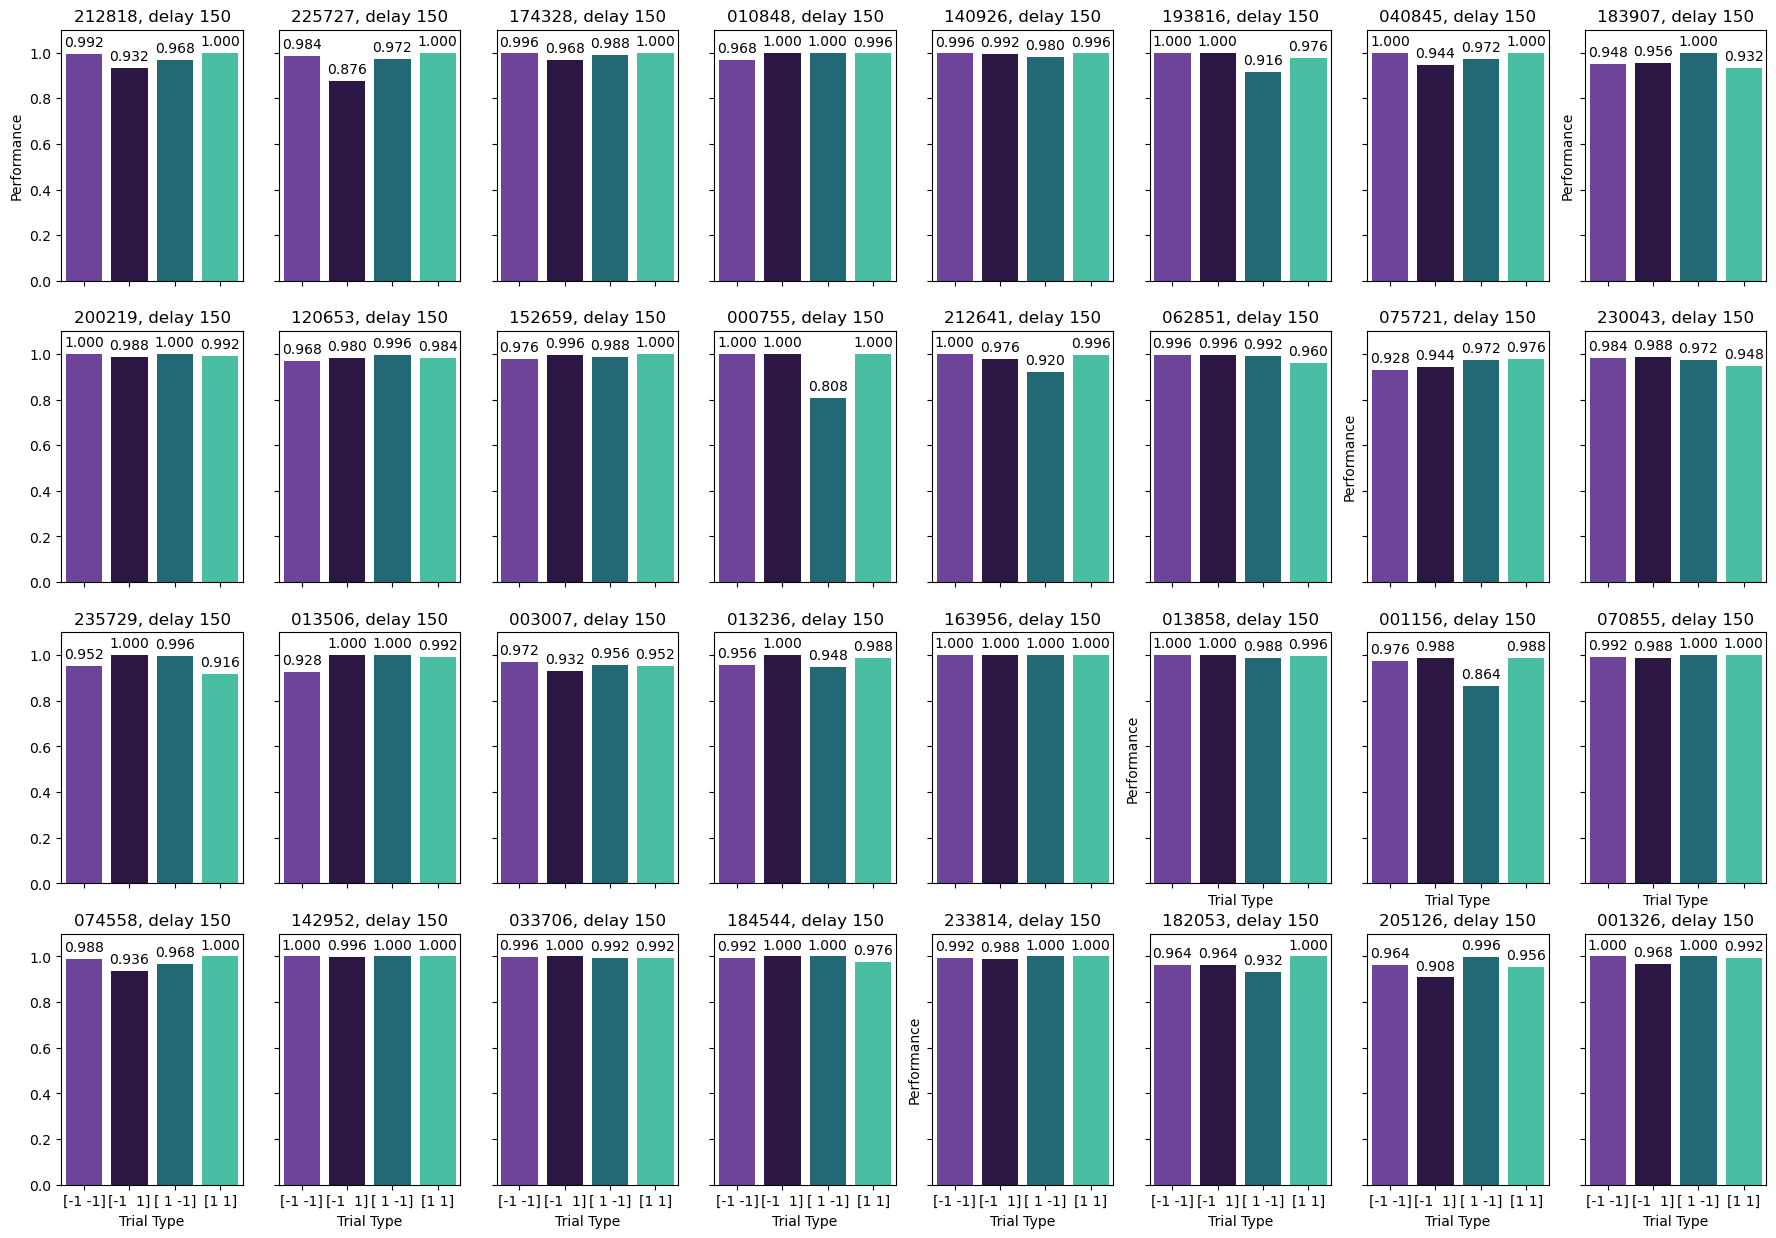

In [10]:
importlib.reload(bhv)

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 7 != 0:
        axs[i].set_ylabel('')
    if i < 21:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 7 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

### delay 50

In [11]:
delay = 50
condn_phrase = 'delay'
condn_num = delay

In [12]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

In [ ]:
# get all of the good models and their performances

good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=150)


Found 90 models with performance between 0.95 and inf


IndexError: index 32 is out of bounds for axis 0 with size 32

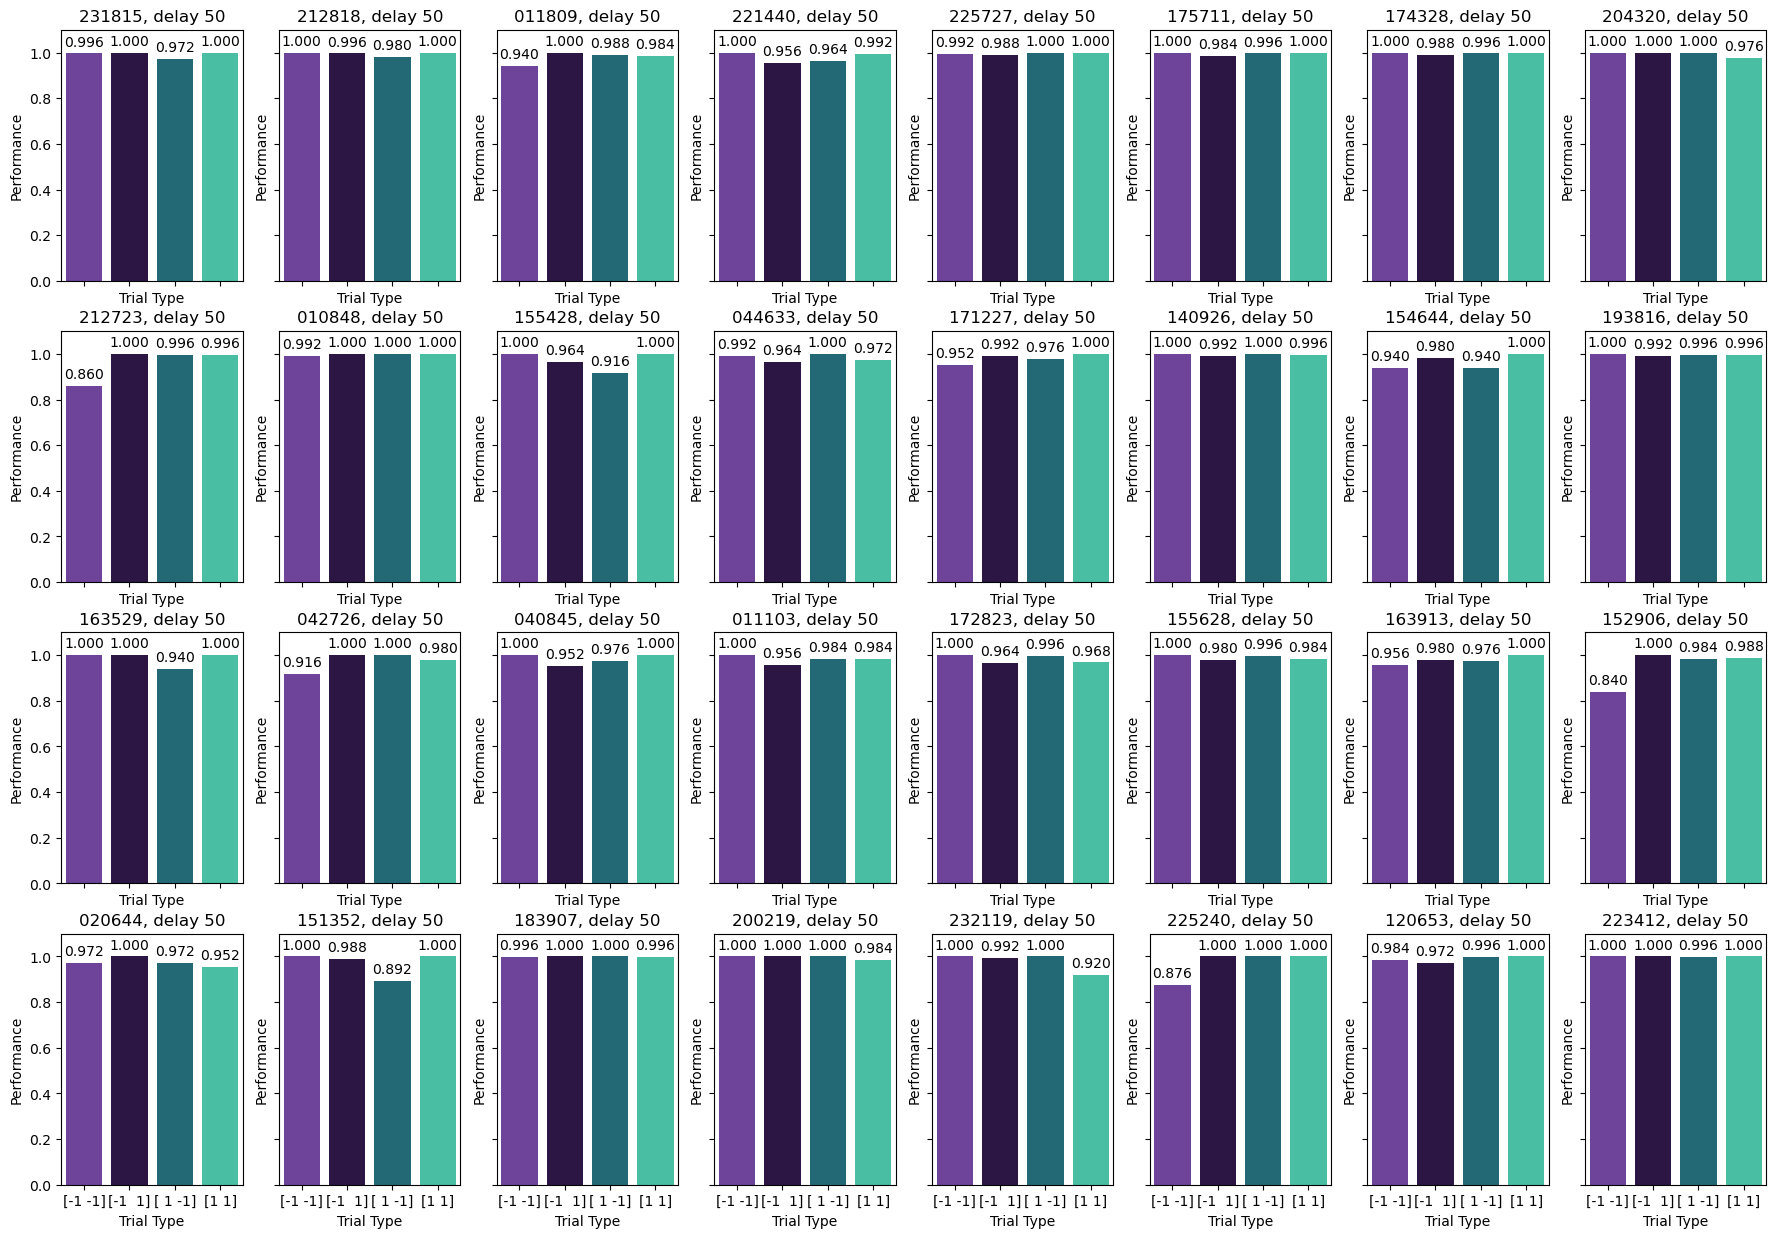

In [14]:
importlib.reload(bhv)

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 7 != 0:
        axs[i].set_ylabel('')
    if i < 21:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 7 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

### compare delay50 and delay150

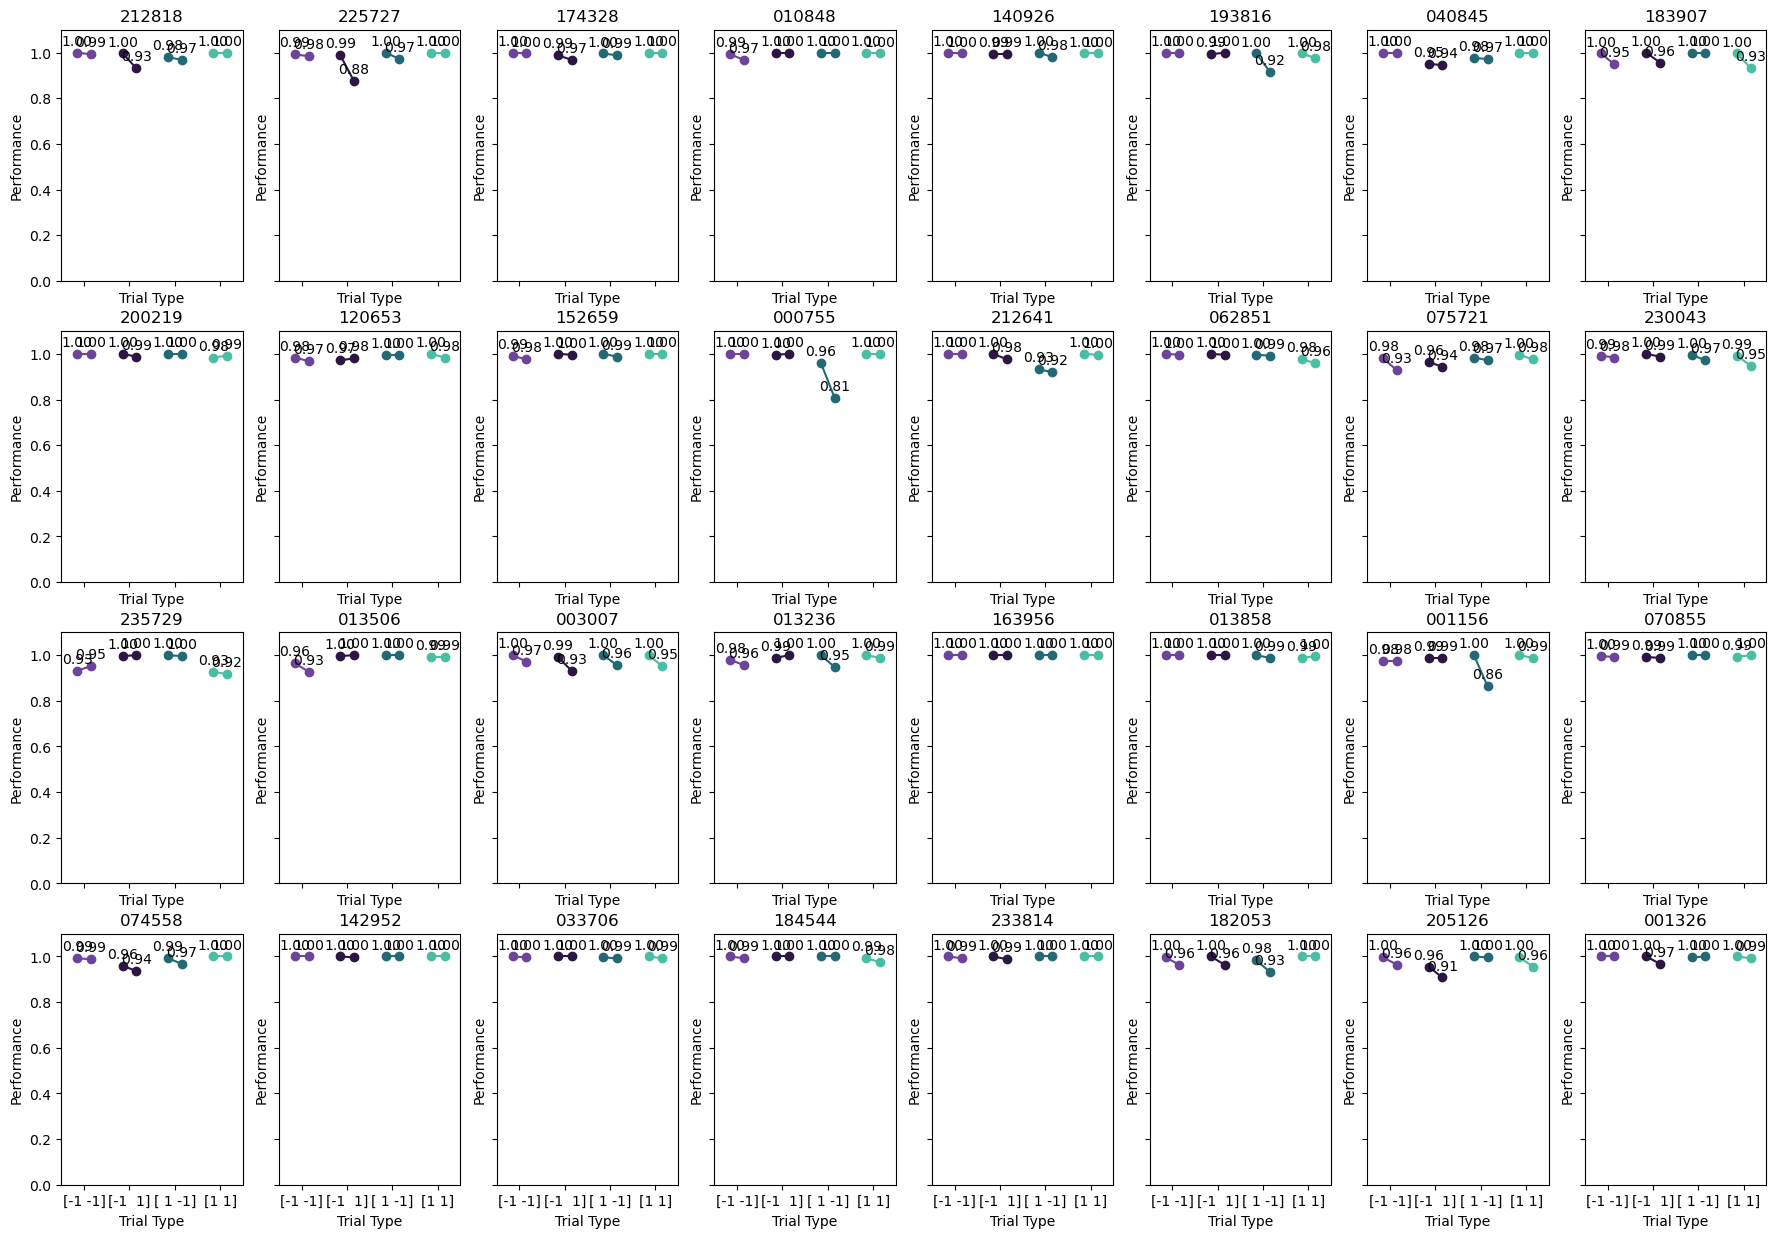

In [5]:
# plot paired comparison of performance for delay=50 and delay=150

fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_paired_trial_performance(model_name, 'delay', 50, 'delay', 150,
                                axs[i_model], title=model_name[-6:])

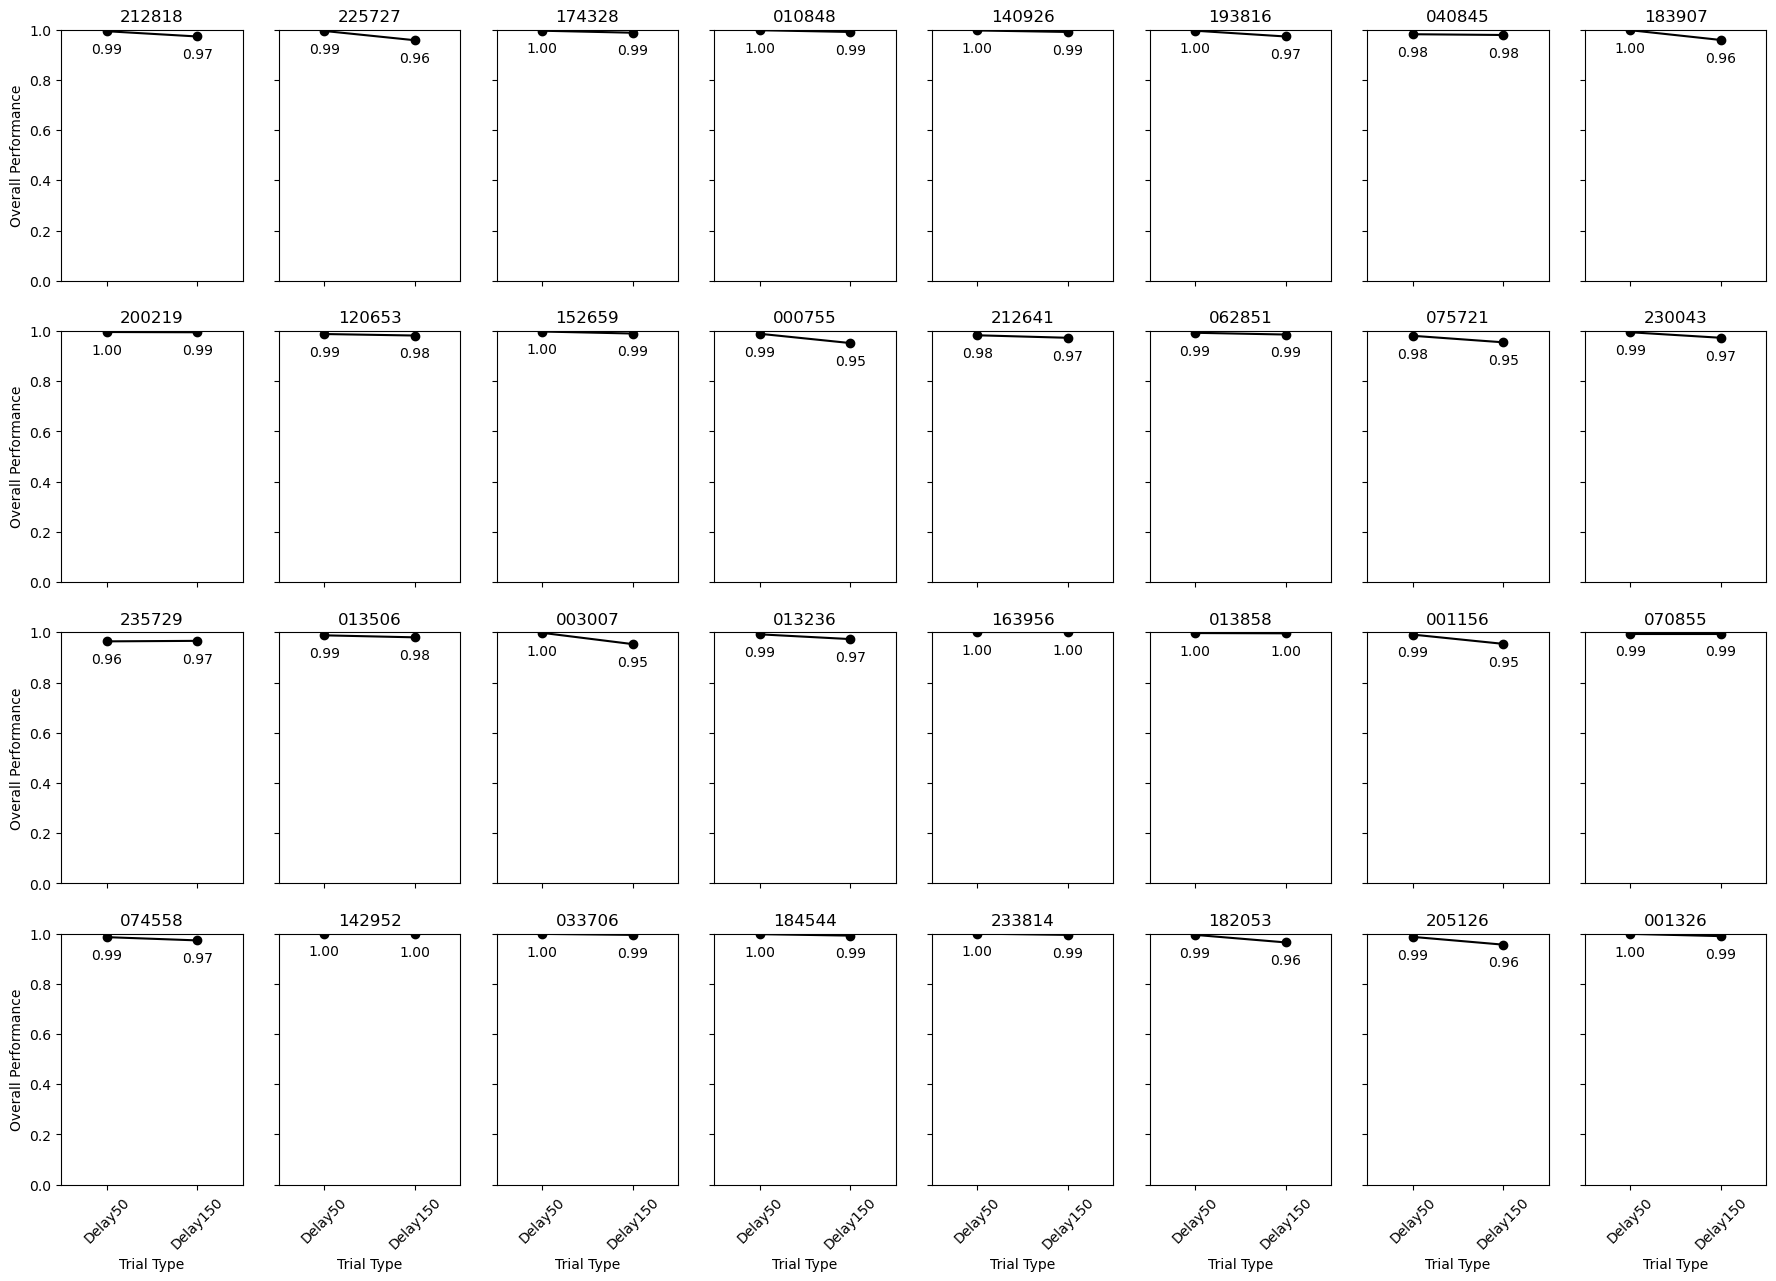

In [8]:
# plot changes in overall model performance

fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    _, trial_perfs_50 = ld.load_bhv_data(model_name, 'delay', 50)
    _, trial_perfs_150 = ld.load_bhv_data(model_name, 'delay', 150)
    axs[i_model].plot([1.25,1.75], [trial_perfs_50.mean(), trial_perfs_150.mean()],
             marker='o', color='black', label=model_name[-6:])
    axs[i_model].text(1.25, trial_perfs_50.mean() - 0.1,
             f'{trial_perfs_50.mean():.2f}', ha='center', va='bottom')
    axs[i_model].text(1.75, trial_perfs_150.mean() - 0.1,
             f'{trial_perfs_150.mean():.2f}', ha='center', va='bottom')
    axs[i_model].set_title(model_name[-6:])
    axs[i_model].set_ylim(0, 1.0)
    axs[i_model].set_xlim(1, 2)
    axs[i_model].set_xticks([1.25, 1.75])
    axs[i_model].set_xticklabels(['Delay50', 'Delay150'], rotation=45)

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 8 != 0:
        axs[i].set_ylabel('')
    if i < 24:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 8 == 0:
        axs[i].set_ylabel('Overall Performance')
plt.show()

### delay 150, lesion untuned presyn

In [2]:
delay = 150
condn_phrase = 'lesionuntuned_delay'
condn_num = delay

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

In [12]:
# get all of the good models and their performances

good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf, 
                                              condn_phrase='delay', condn_num=condn_num)


Found 32 models with performance between 0.95 and inf


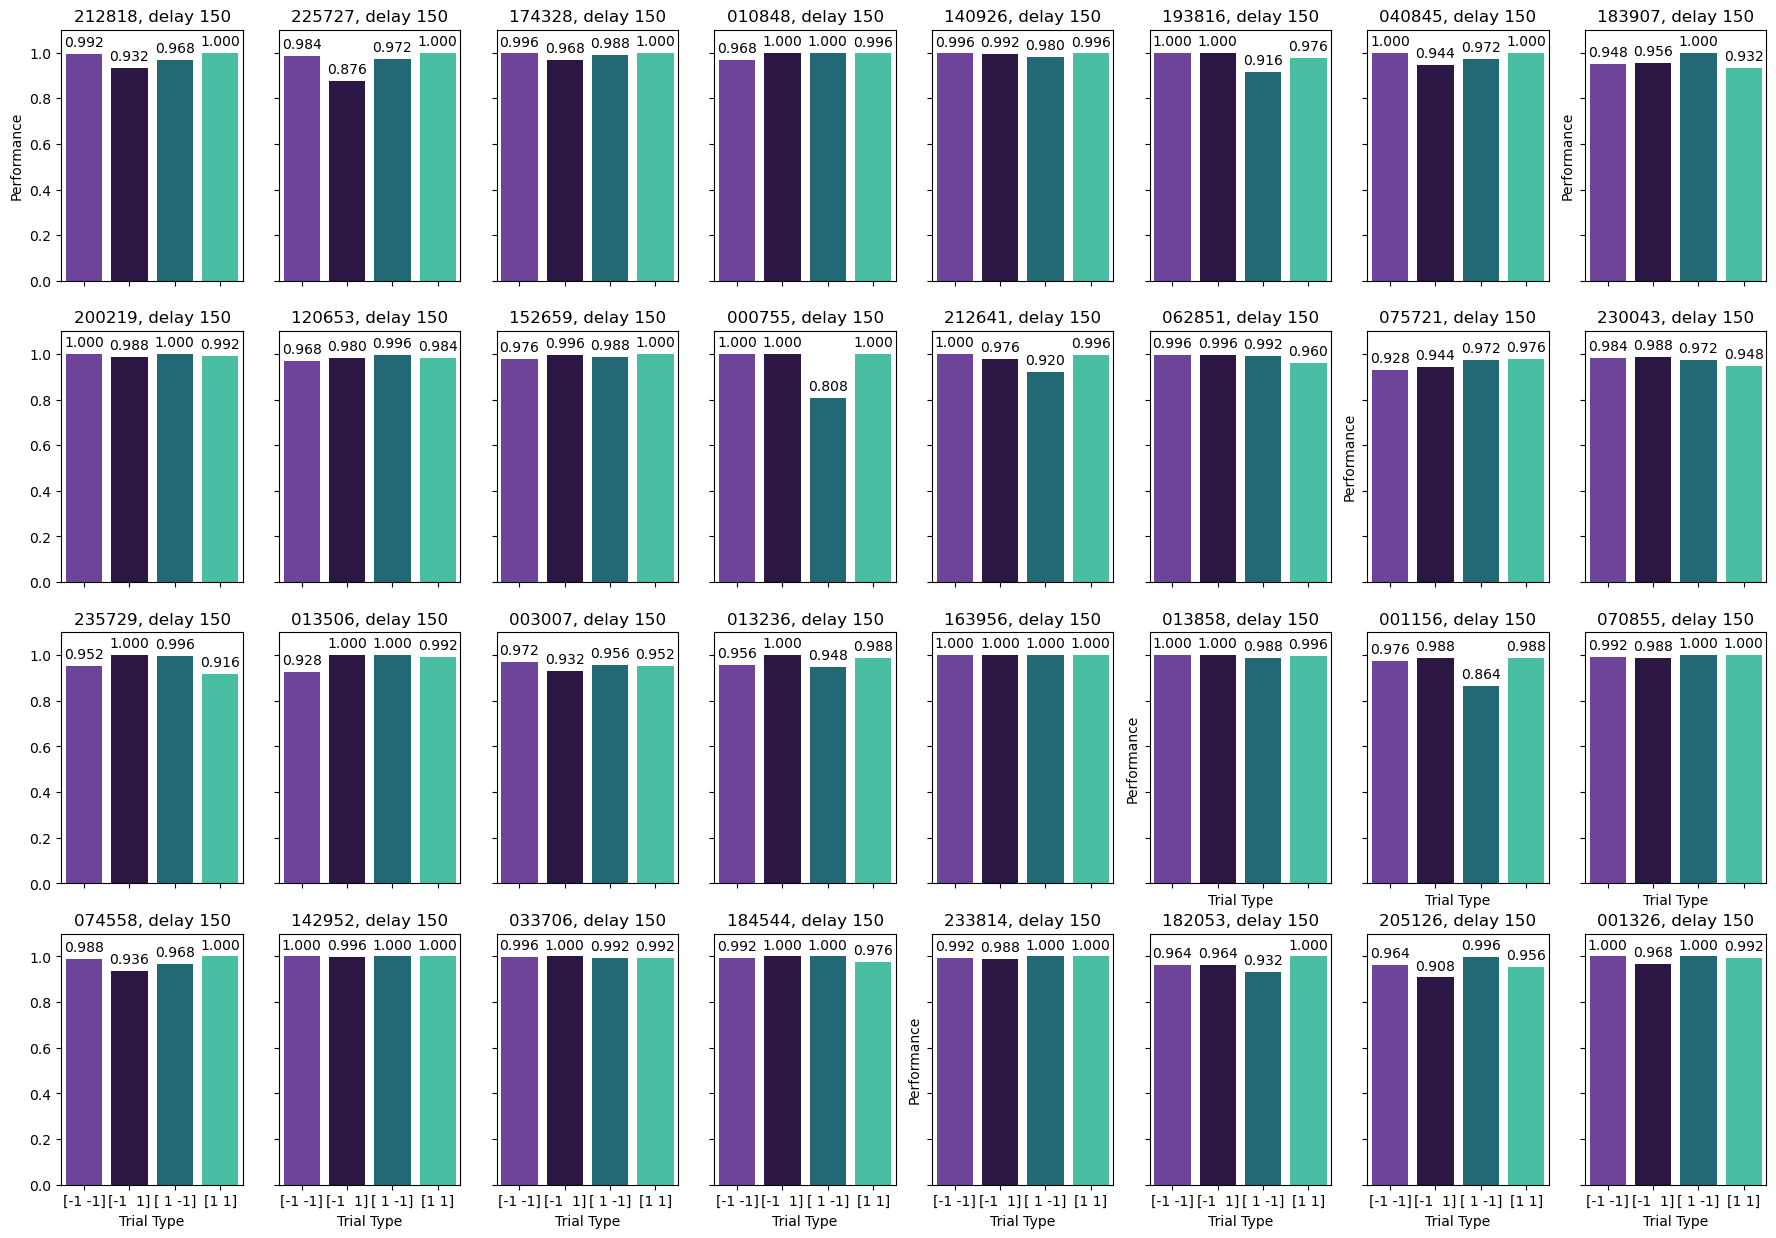

In [ ]:
# plot performance without lesions

importlib.reload(bhv)

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_trial_performance(model_name, 'delay', condn_num, axs[i_model])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 7 != 0:
        axs[i].set_ylabel('')
    if i < 21:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 7 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

In [15]:
ld.find_files_keywords(f'{all_models_dir}/{model_name}', ['bhvdata', f'{condn_phrase}{condn_num}'])[0]

'/home/nuttidalab/Documents/renee/all_DMS_models//Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_142952/bhvdata_raw_lesionuntuned_delay150.mat'

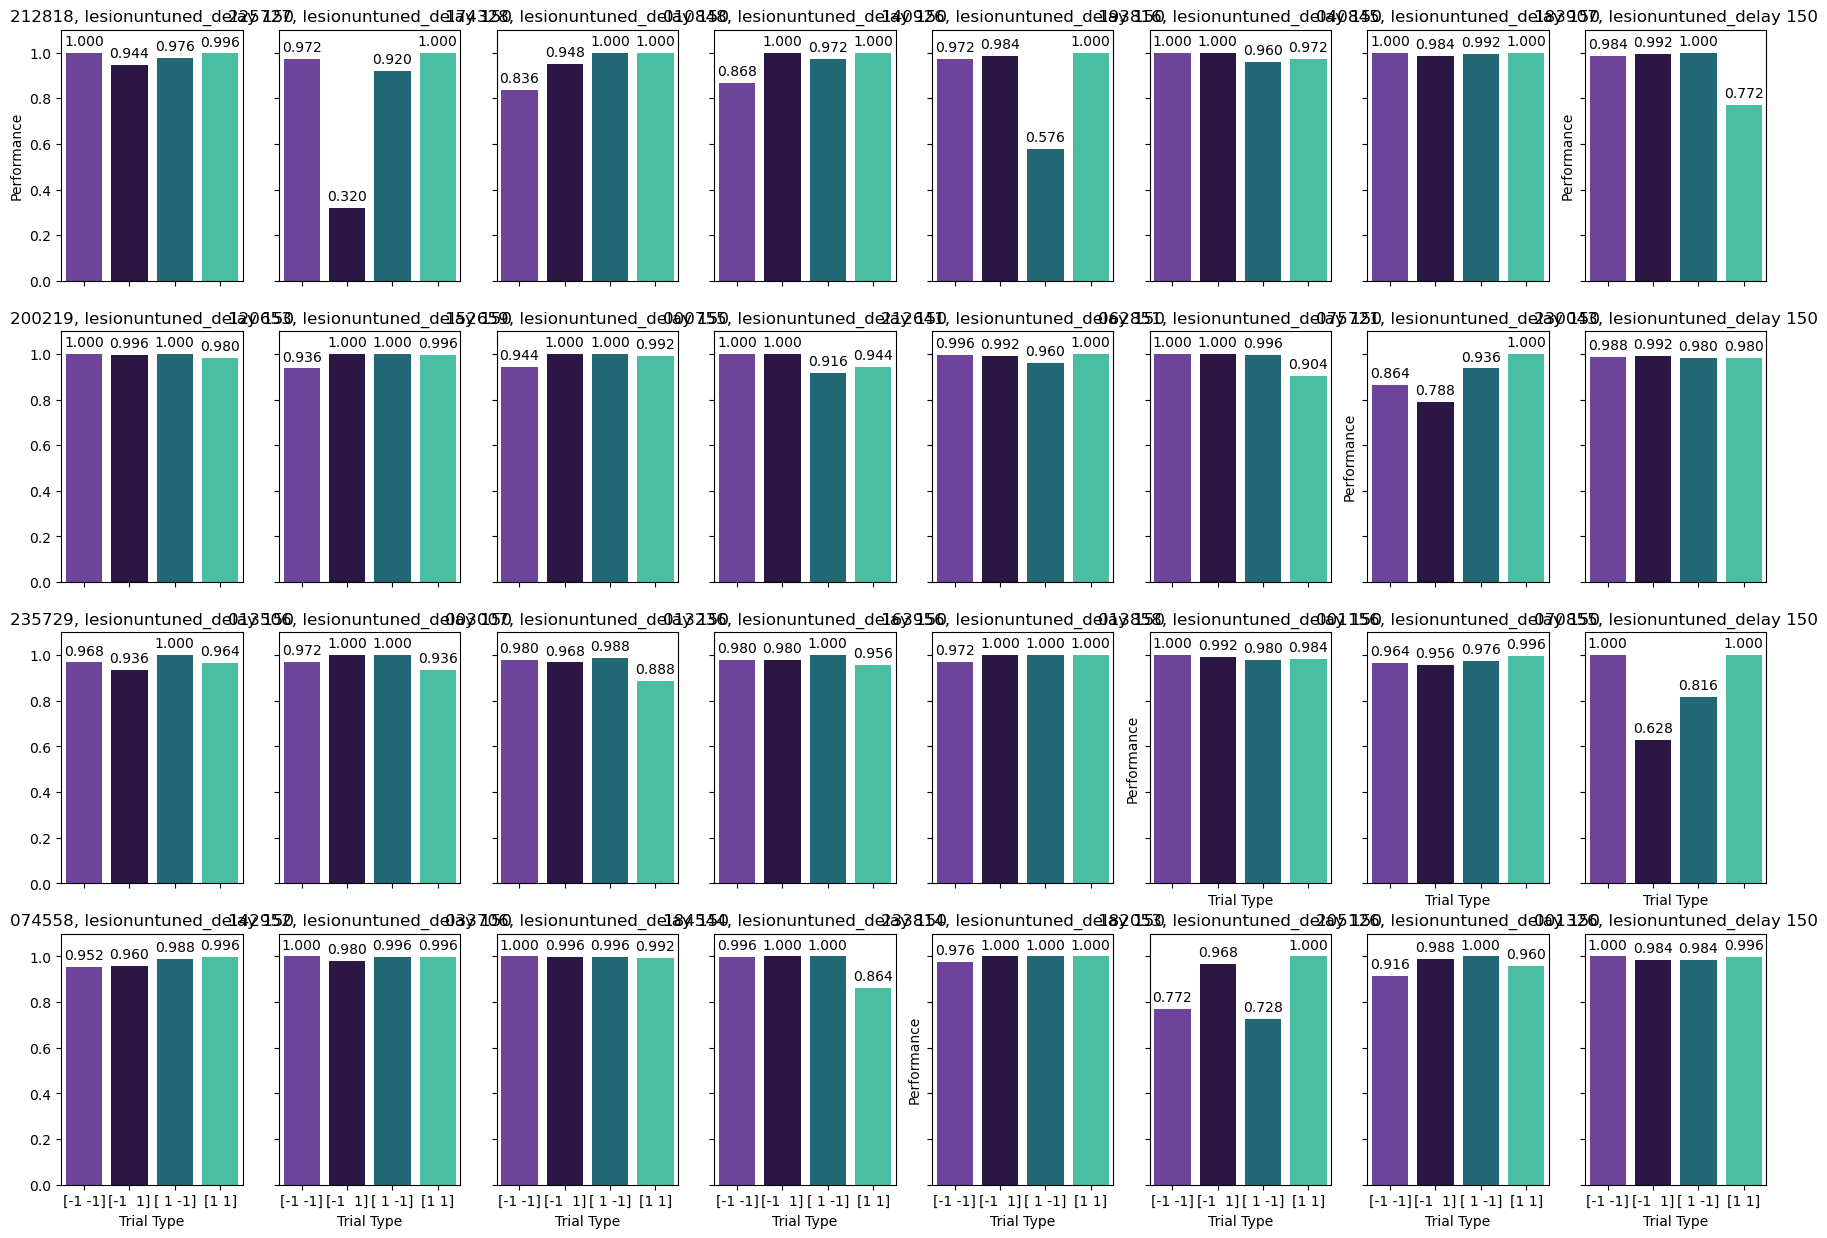

In [16]:
# plot performance when lesioning the untuned neurons

importlib.reload(bhv)

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_trial_performance(model_name, condn_phrase, condn_num, axs[i_model])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 7 != 0:
        axs[i].set_ylabel('')
    if i < 21:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 7 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

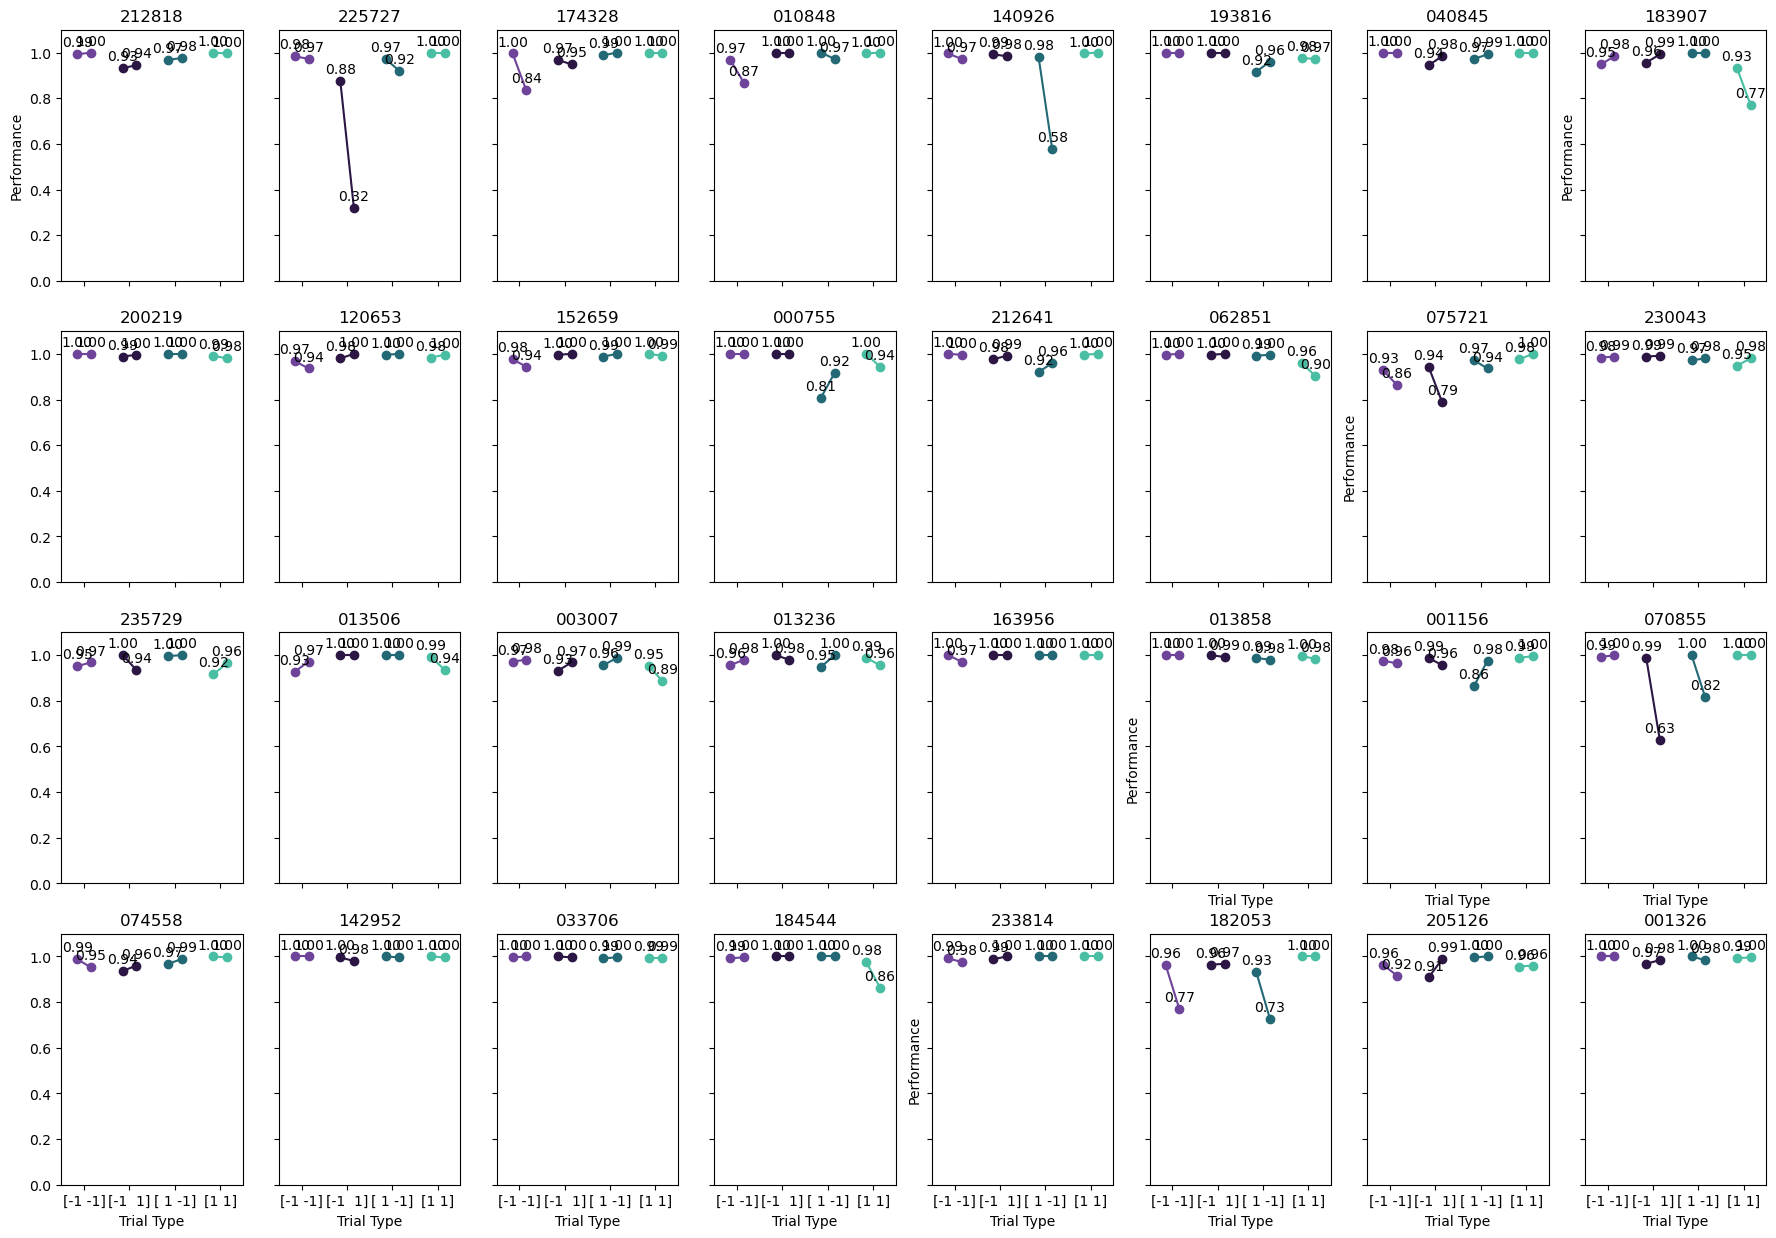

In [20]:
# plot paired comparison of performance with and without lesions
importlib.reload(bhv)

fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_paired_trial_performance(model_name, 'delay', condn_num, 'lesionuntuned_delay', condn_num,
                                axs[i_model], title=model_name[-6:])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 7 != 0:
        axs[i].set_ylabel('')
    if i < 21:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 7 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

### delay 150, untuned lesion postsynaptic

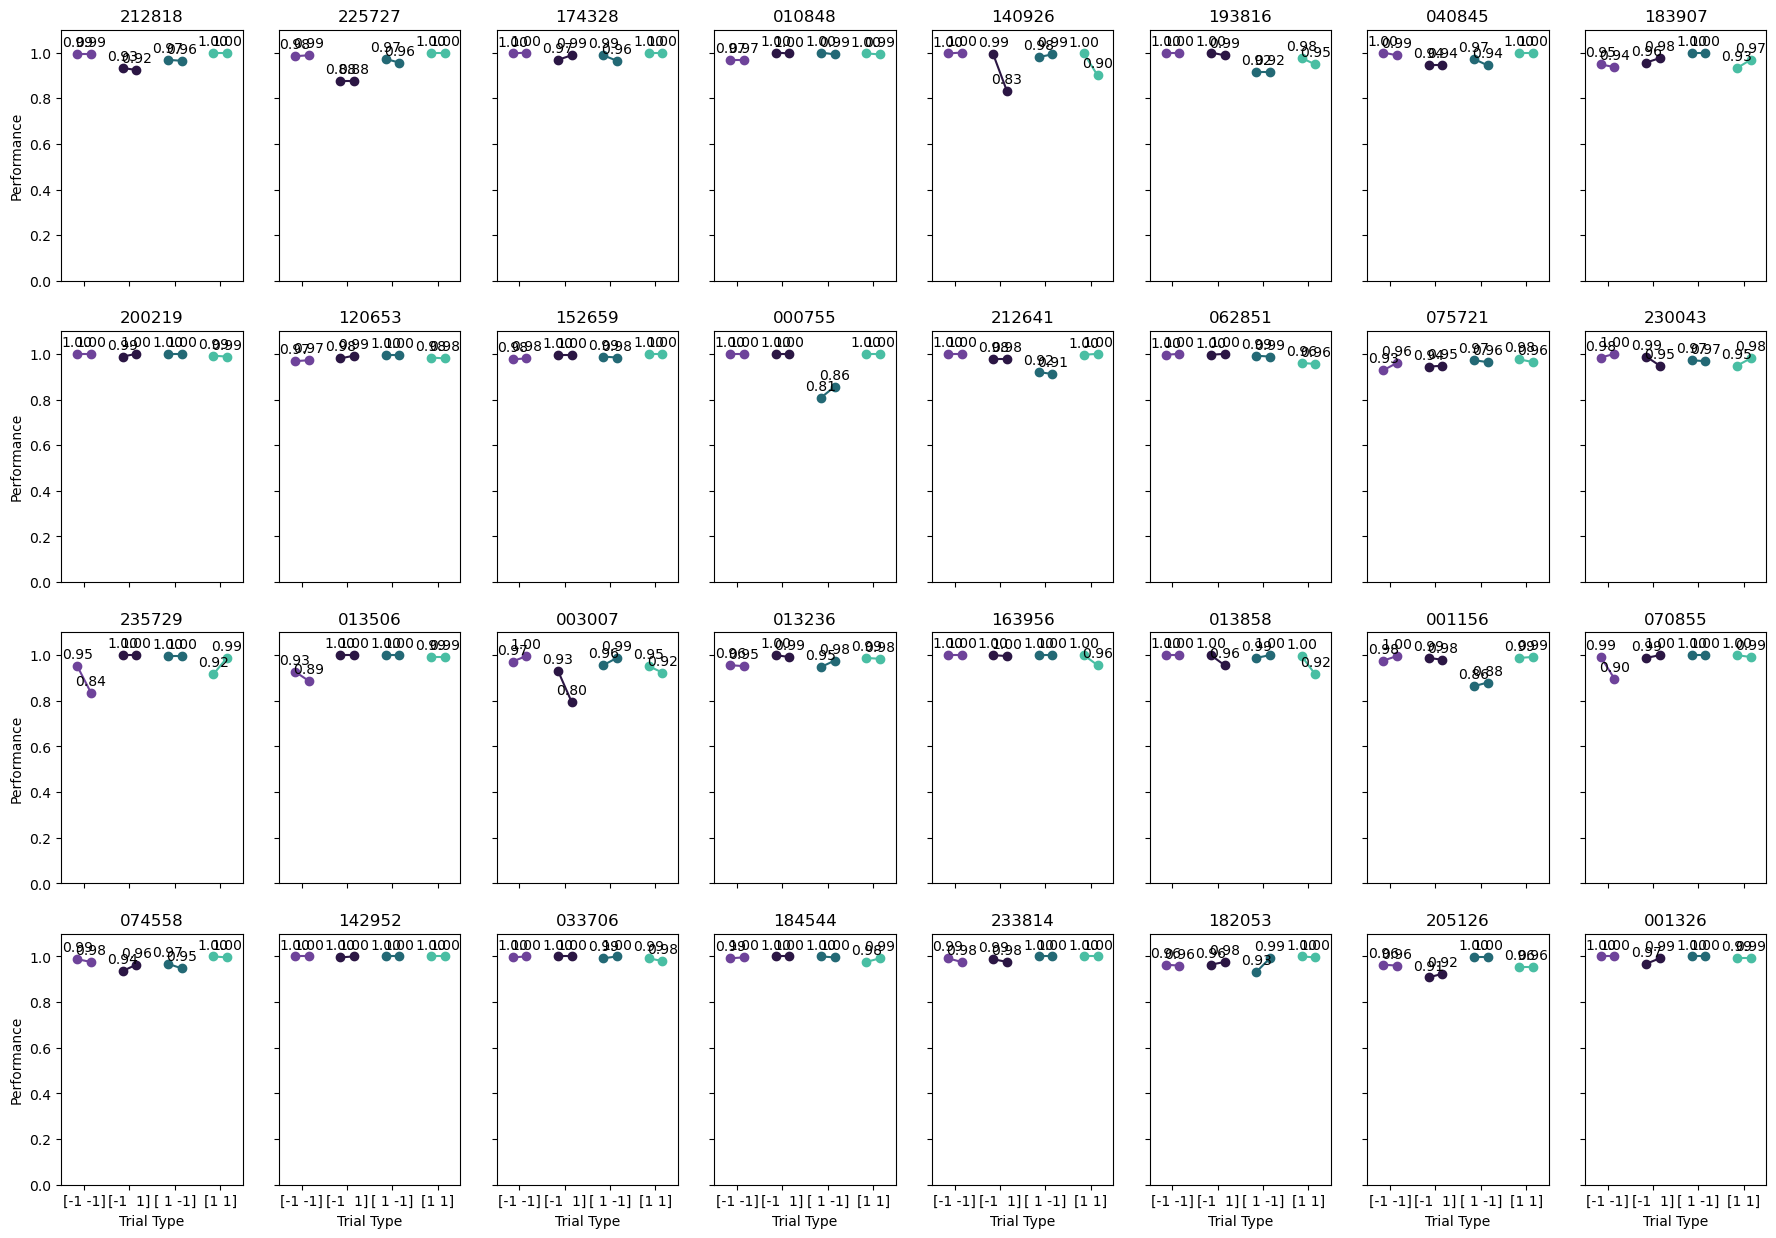

In [6]:
# plot paired comparison of performance with and without lesions
importlib.reload(bhv)

fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_paired_trial_performance(model_name, 'delay', condn_num, 'lesionuntunedpost_delay', condn_num,
                                axs[i_model], title=model_name[-6:])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 8 != 0:
        axs[i].set_ylabel('')
    if i < 24:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 8 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

In [7]:
def plot_three_trial_performance(model_name, condn_phrase1, condn_num1, condn_phrase2, condn_num2, condn_phrase3, condn_num3, ax=None, title=None):
    """
    Plot the paired trial performance for two conditions
    """
    # Load the data
    trial_labels1, trial_perfs1 = ld.load_bhv_data(model_name, condn_phrase1, condn_num1)
    trial_labels2, trial_perfs2 = ld.load_bhv_data(model_name, condn_phrase2, condn_num2)
    trial_label3, trial_perfs3 = ld.load_bhv_data(model_name, condn_phrase3, condn_num3)

    # Get the unique trial types and their indices
    unique_labels = np.unique(trial_labels1, axis=0)
    stims, colors = ld.get_trialtype_colors()

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    for i in range(unique_labels.shape[0]):
        trial_type = unique_labels[i]
        trial_indices1 = np.where(np.all(trial_labels1 == trial_type, axis=1))[0]
        trial_indices2 = np.where(np.all(trial_labels2 == trial_type, axis=1))[0]
        trial_indices3 = np.where(np.all(trial_label3 == trial_type, axis=1))[0]

        if len(trial_indices1) > 0 and len(trial_indices2) > 0 and len(trial_indices3) > 0:
            trial_performance1 = trial_perfs1[trial_indices1]
            trial_performance2 = trial_perfs2[trial_indices2]
            trial_performance3 = trial_perfs3[trial_indices3]

            # Plot paired performance
            ax.plot([i - 0.15, i, i + 0.15], [trial_performance1.mean(), trial_performance2.mean(), trial_performance3.mean()], color=colors[i], marker='o')
            # ax.errorbar(i - 0.15, trial_performance1.mean(), yerr=trial_performance1.std(), fmt='o', color=colors[i], capsize=5)
            # ax.errorbar(i + 0.15, trial_performance2.mean(), yerr=trial_performance2.std(), fmt='o', color=colors[i], capsize=5)

            # Print performance on top of points
            ax.text(i - 0.25, trial_performance1.mean() + 0.04, f'{trial_performance1.mean():.2f}', ha='center', va='bottom')
            ax.text(i, trial_performance2.mean() + 0.04, f'{trial_performance2.mean():.2f}', ha='center', va='bottom')
            ax.text(i + 0.25, trial_performance3.mean() + 0.04, f'{trial_performance3.mean():.2f}', ha='center', va='bottom')

    ax.set_xticks(range(len(unique_labels)), [str(label) for label in unique_labels])
    ax.set_xlim(-0.5, len(unique_labels) - 0.5)
    ax.set_ylim(0, 1.1)
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f'{model_name[-6:]}, {condn_phrase1} {condn_num1} vs {condn_phrase2} {condn_num2} vs {condn_phrase3} {condn_num3}')
    ax.set_xlabel('Trial Type')
    ax.set_ylabel('Performance')
    
    return ax

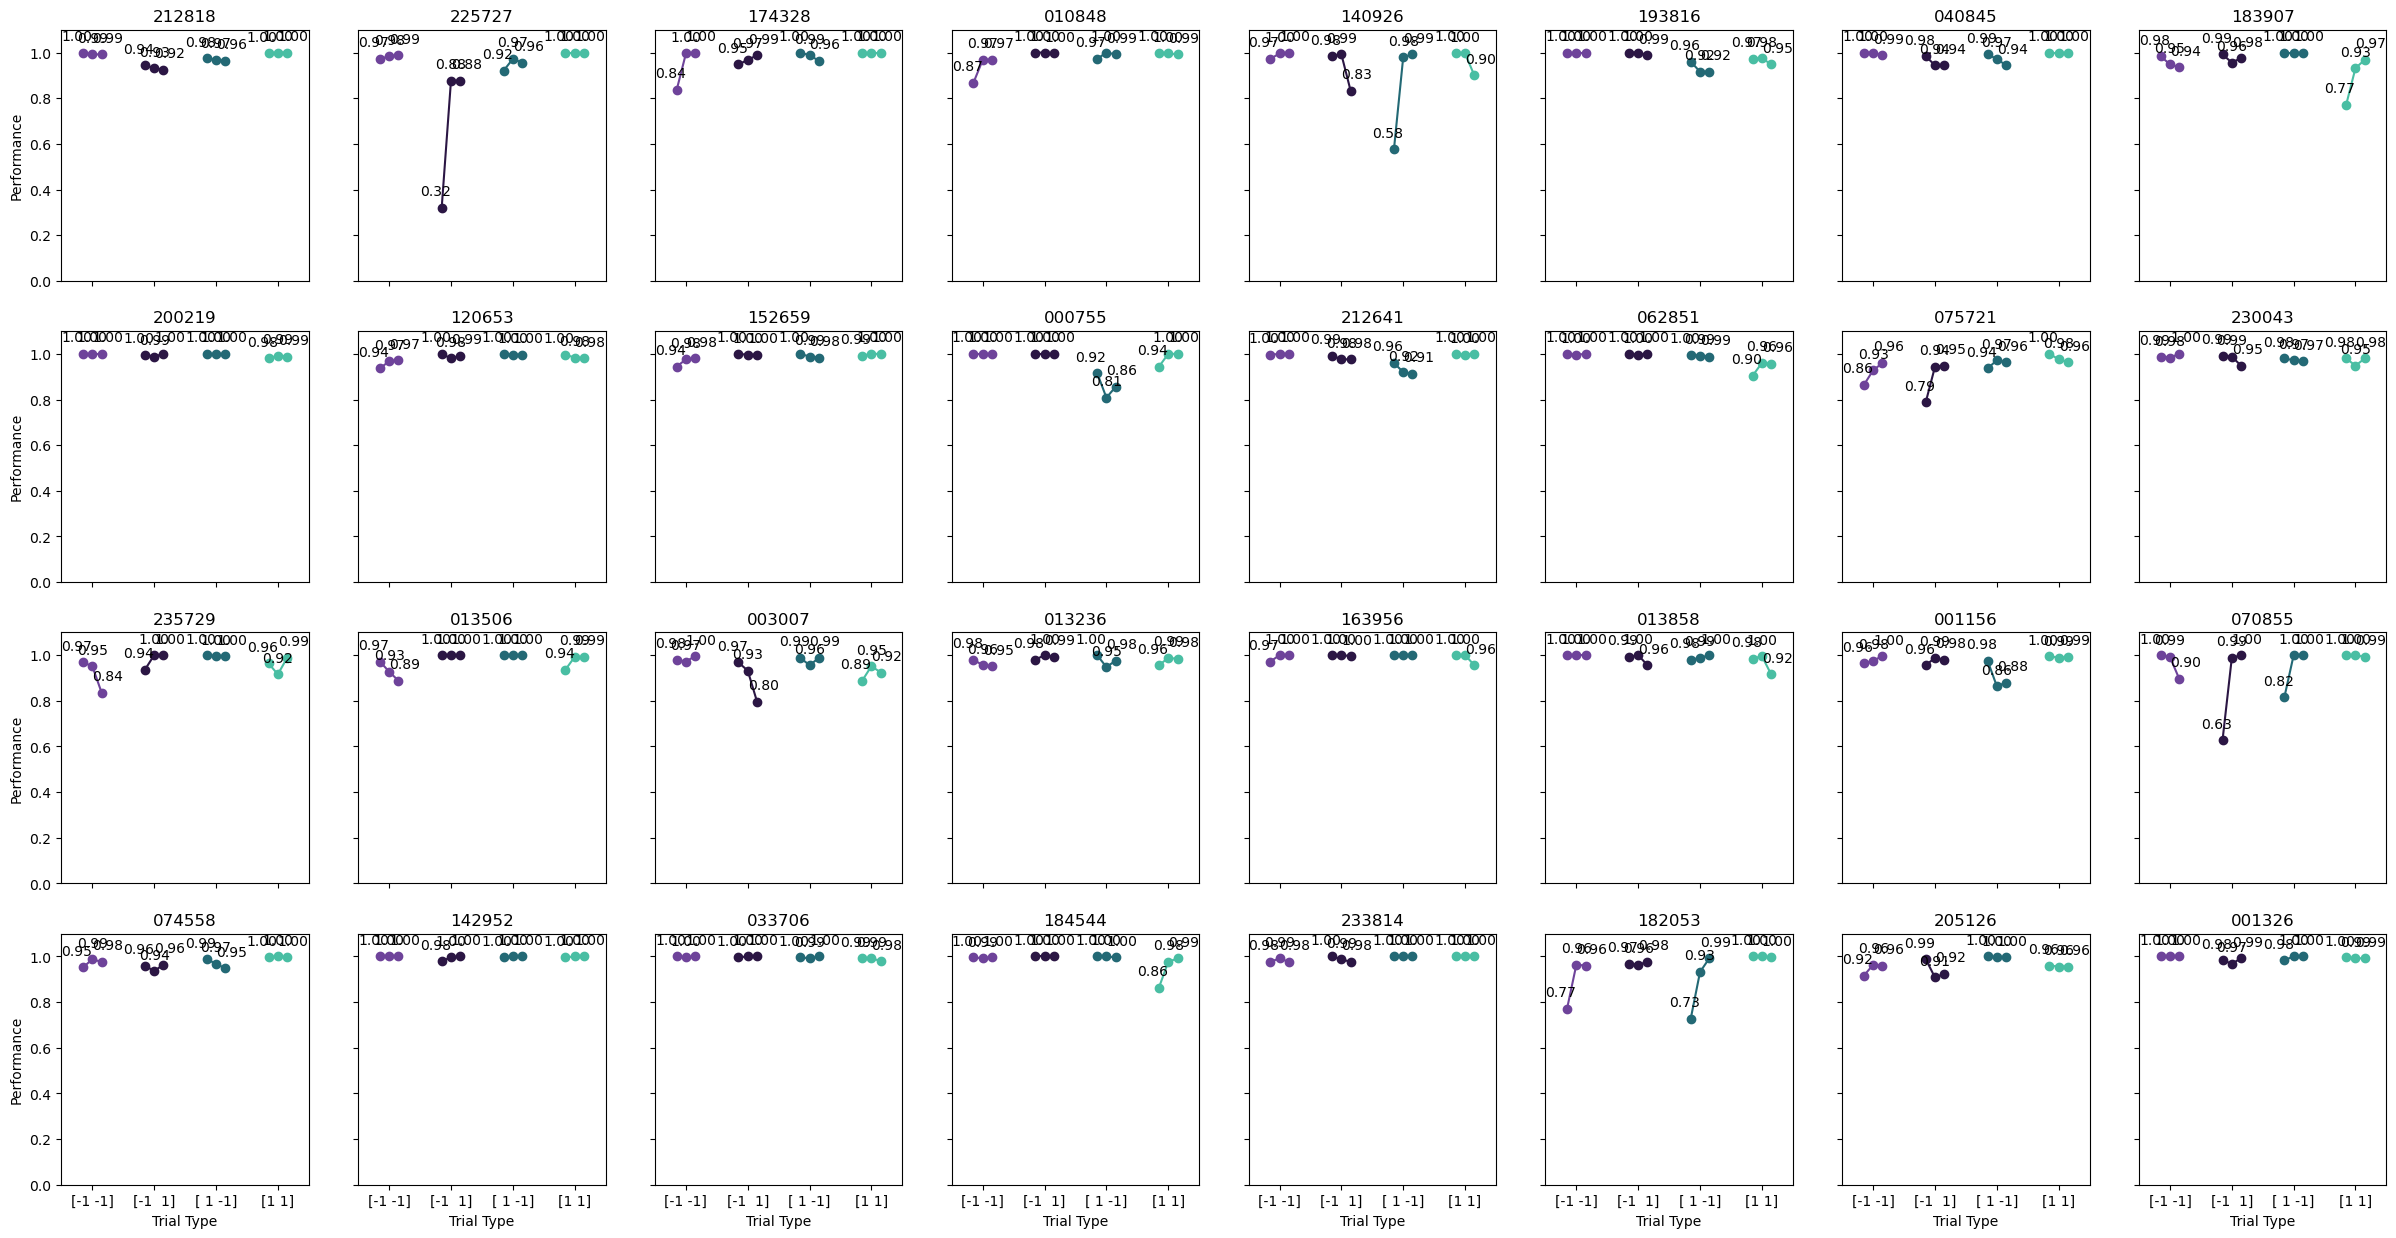

In [8]:
# plot paired comparison of performance with and without lesions
importlib.reload(bhv)

fig, axs = plt.subplots(4, 8, figsize=(30, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    plot_three_trial_performance(model_name, 'lesionuntuned_delay', condn_num, 'delay', condn_num, 'lesionuntunedpost_delay', condn_num,
                                axs[i_model], title=model_name[-6:])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 8 != 0:
        axs[i].set_ylabel('')
    if i < 24:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 8 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

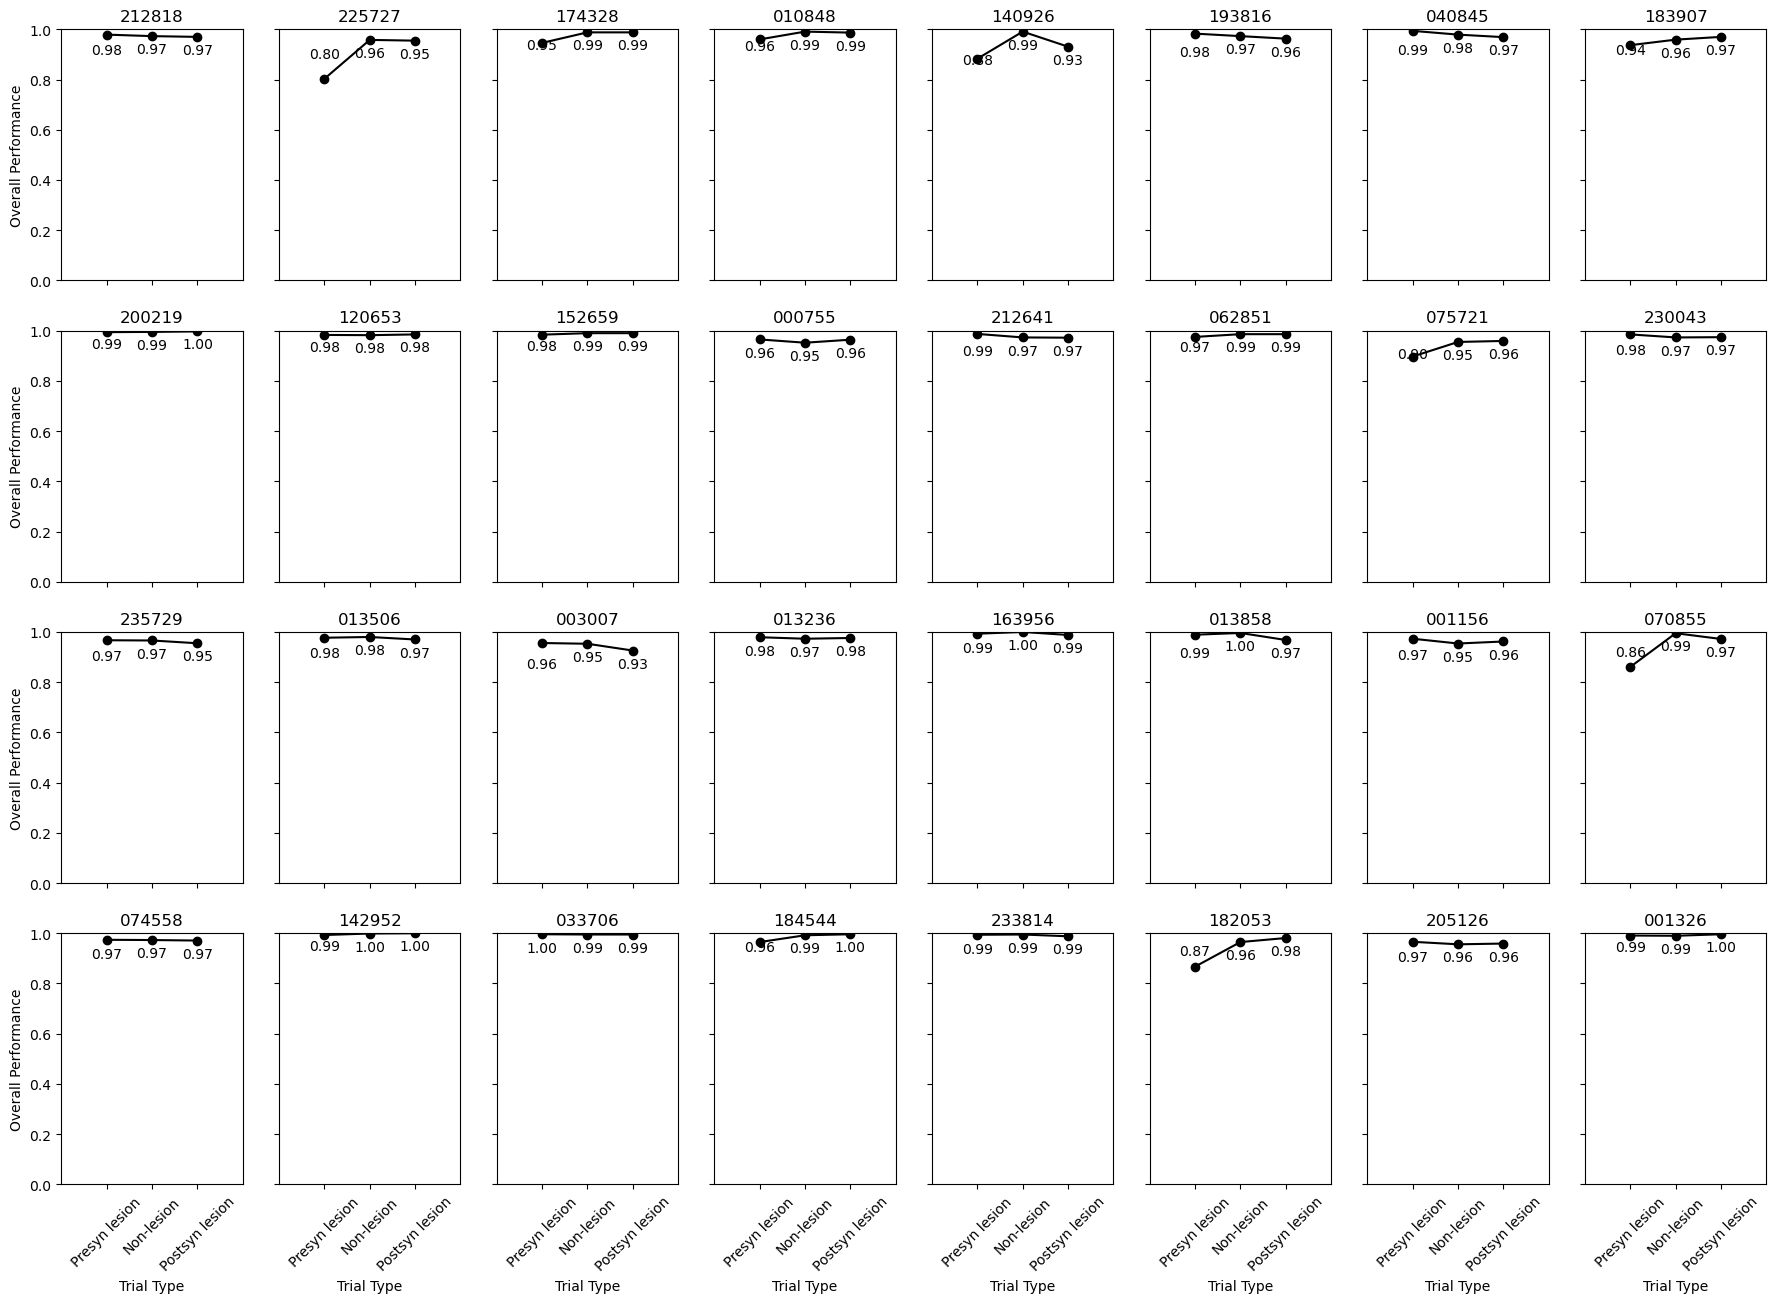

In [11]:
# plot changes in overall model performance

fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    _, trial_perfs_prelesion = ld.load_bhv_data(model_name, 'lesionuntuned_delay', condn_num)
    _, trial_perfs_nonlesion = ld.load_bhv_data(model_name, 'delay', condn_num)
    _, trial_perfs_postlesion = ld.load_bhv_data(model_name, 'lesionuntunedpost_delay', condn_num)
    axs[i_model].plot([1.25,1.5,1.75], [trial_perfs_prelesion.mean(), trial_perfs_nonlesion.mean(), trial_perfs_postlesion.mean()],
             marker='o', color='black', label=model_name[-6:])
    axs[i_model].text(1.25, trial_perfs_postlesion.mean() - 0.08,
             f'{trial_perfs_prelesion.mean():.2f}', ha='center', va='bottom')
    axs[i_model].text(1.5, trial_perfs_nonlesion.mean() - 0.08,
             f'{trial_perfs_nonlesion.mean():.2f}', ha='center', va='bottom')
    axs[i_model].text(1.75, trial_perfs_postlesion.mean() - 0.08,
             f'{trial_perfs_postlesion.mean():.2f}', ha='center', va='bottom')
    axs[i_model].set_title(model_name[-6:])
    axs[i_model].set_ylim(0, 1.0)
    axs[i_model].set_xlim(1, 2)
    axs[i_model].set_xticks([1.25, 1.5, 1.75])
    axs[i_model].set_xticklabels(['Presyn lesion', 'Non-lesion', 'Postsyn lesion'], rotation=45)

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 8 != 0:
        axs[i].set_ylabel('')
    if i < 24:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 8 == 0:
        axs[i].set_ylabel('Overall Performance')
plt.show()

### null lesioning

In [12]:
delay = 150
condn_phrase = 'lesionuntunednull_delay'
condn_num = delay

In [13]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

In [14]:
# get all of the good models and their performances

good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf, 
                                              condn_phrase='delay', condn_num=condn_num)


Found 32 models with performance between 0.95 and inf


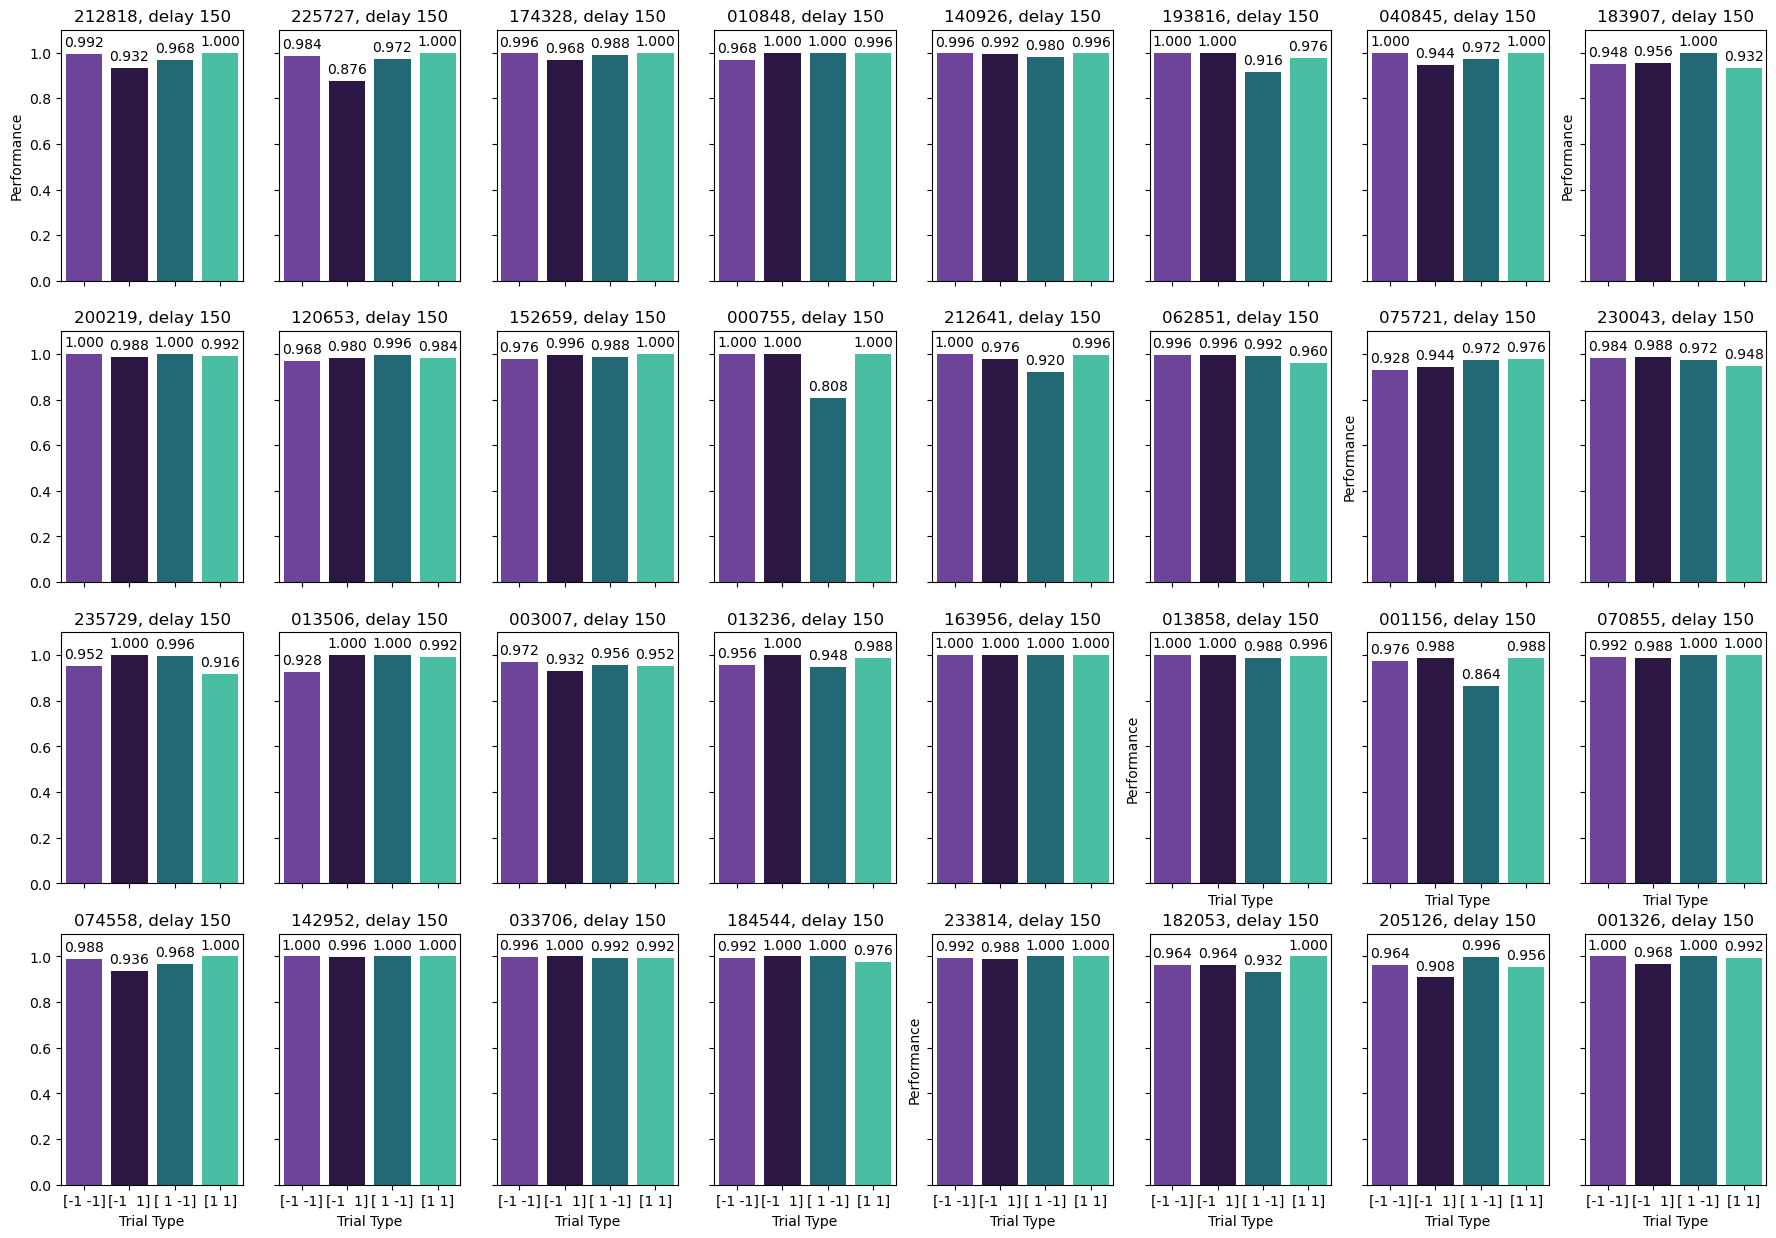

In [15]:
# plot performance without lesions

importlib.reload(bhv)

stims, colors = bhv.get_trialtype_colors()

# plot a histogram for each model
fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_trial_performance(model_name, 'delay', condn_num, axs[i_model])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 7 != 0:
        axs[i].set_ylabel('')
    if i < 21:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 7 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

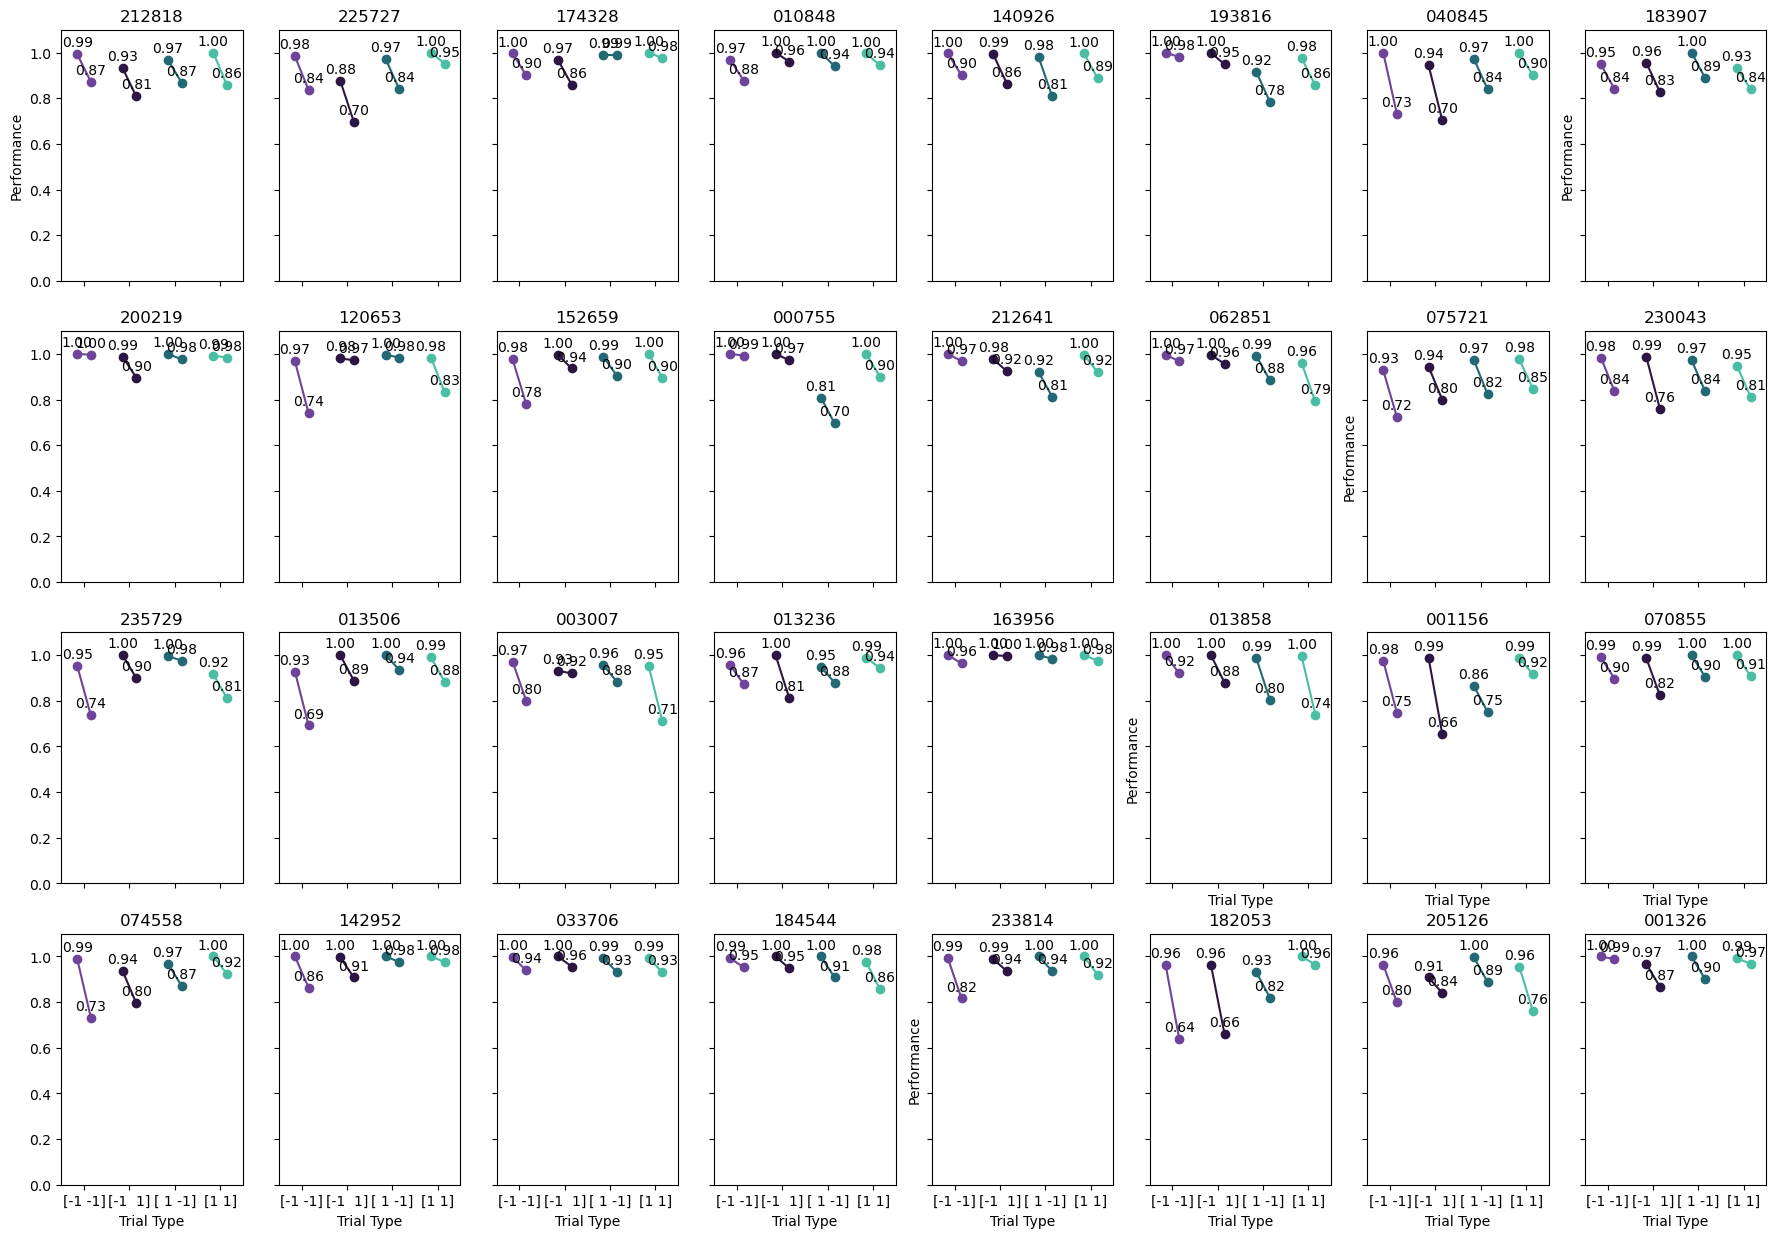

In [16]:
# plot paired comparison of performance with and without lesions
importlib.reload(bhv)

fig, axs = plt.subplots(4, 8, figsize=(22, 15), sharex=True, sharey=True)
axs = axs.flatten()
for i_model, model_name in enumerate(good_models):
    bhv.plot_paired_trial_performance(model_name, 'delay', condn_num, 'lesionuntunednull_delay', condn_num,
                                axs[i_model], title=model_name[-6:])

# remove axis labels for all but the left and bottom plots
for i in range(len(axs)):
    if i % 7 != 0:
        axs[i].set_ylabel('')
    if i < 21:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Trial Type')
    if i % 7 == 0:
        axs[i].set_ylabel('Performance')
plt.show()

#### boxplots for good and bad, lesioning null

In [18]:
good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf, 
                                              condn_phrase='delay', condn_num=condn_num)

bad_models, bad_perfs = ld.get_models_by_perf(low_cutoff=0.6, high_cutoff=0.8, 
                                              condn_phrase='delay', condn_num=condn_num)


Found 32 models with performance between 0.95 and inf
Found 28 models with performance between 0.6 and 0.8


/tmp/ipykernel_1976755/2885319440.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([good_model_perfs, good_model_perfs_lesion_null, bad_model_perfs, bad_model_perfs_lesion_null],


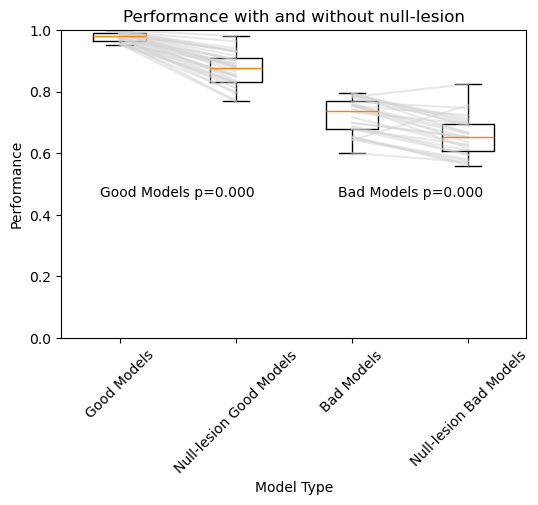

In [29]:
# plot paired comparison of performance with and without lesions
importlib.reload(bhv)

plt.figure(figsize=(6,4))
good_model_perfs = []
good_model_perfs_lesion_null = []
bad_model_perfs = []
bad_model_perfs_lesion_null = []
for i_model, model_name in enumerate(good_models):
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'lesionuntunednull_delay', condn_num)
    good_model_perfs_lesion_null.append(trial_perfs.mean())
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'delay', condn_num)
    good_model_perfs.append(trial_perfs.mean())
for i_model, model_name in enumerate(bad_models):
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'lesionuntunednull_delay', condn_num)
    bad_model_perfs_lesion_null.append(trial_perfs.mean())
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'delay', condn_num)
    bad_model_perfs.append(trial_perfs.mean())
    
# box plot
plt.boxplot([good_model_perfs, good_model_perfs_lesion_null, bad_model_perfs, bad_model_perfs_lesion_null], 
               labels=['Good Models', 'Null-lesion Good Models','Bad Models', 'Null-lesion Bad Models'])

# draw light lines between the pairs
for i in range(len(good_model_perfs)):
    plt.plot([1, 2], [good_model_perfs[i], good_model_perfs_lesion_null[i]], color='lightgray', alpha=0.5)
for i in range(len(bad_model_perfs)):
    plt.plot([3, 4], [bad_model_perfs[i], bad_model_perfs_lesion_null[i]], color='lightgray', alpha=0.5)

# add stats, wilcoxon signed-rank test
from scipy.stats import wilcoxon
good_wilcoxon = wilcoxon(good_model_perfs, good_model_perfs_lesion_null)
bad_wilcoxon = wilcoxon(bad_model_perfs, bad_model_perfs_lesion_null)
plt.text(1.5, 0.45, f'Good Models p={good_wilcoxon.pvalue:.3f}', ha='center', va='bottom')
plt.text(3.5, 0.45, f'Bad Models p={bad_wilcoxon.pvalue:.3f}', ha='center', va='bottom')
# plt.axhline(0.95, color='red', linestyle='--', label='Performance Threshold')
# plt.legend()


plt.title('Performance with and without null-lesion')
plt.ylabel('Performance')
plt.ylim(0, 1.0)
plt.xticks([1,2,3,4], ['Good Models', 'Null-lesion Good Models', 'Bad Models', 'Null-lesion Bad Models'], rotation=45)
plt.xlabel('Model Type')
plt.show()

In [31]:
np.where(np.array(bad_model_perfs) - np.array(bad_model_perfs_lesion_null) < 0)[0]

array([ 5, 21])

In [32]:
print(bad_models[5])
print(bad_models[21])

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_005938


/tmp/ipykernel_1976755/2753647581.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([good_model_perfs_untuned_lesion, good_model_perfs, good_model_perfs_lesion_null, bad_model_perfs_untuned_lesion, bad_model_perfs, bad_model_perfs_lesion_null],


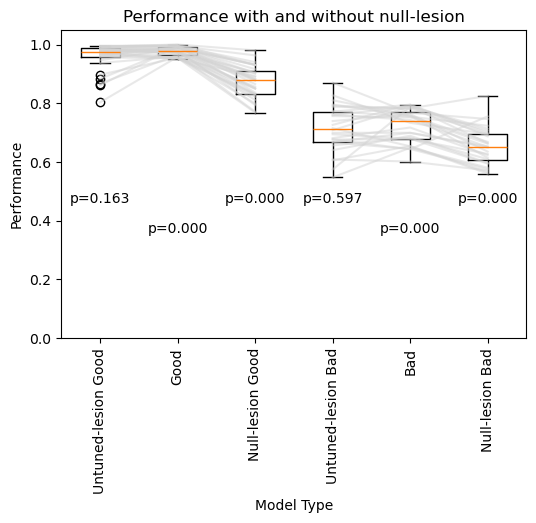

In [41]:
# plot paired comparison of performance with and without lesions
importlib.reload(bhv)

plt.figure(figsize=(6,4))
good_model_perfs_untuned_lesion = []
good_model_perfs = []
good_model_perfs_lesion_null = []
bad_model_perfs_untuned_lesion = []
bad_model_perfs = []
bad_model_perfs_lesion_null = []
for i_model, model_name in enumerate(good_models):
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'lesionuntuned_delay', condn_num)
    good_model_perfs_untuned_lesion.append(trial_perfs.mean())
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'lesionuntunednull_delay', condn_num)
    good_model_perfs_lesion_null.append(trial_perfs.mean())
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'delay', condn_num)
    good_model_perfs.append(trial_perfs.mean())
for i_model, model_name in enumerate(bad_models):
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'lesionuntuned_delay', condn_num)
    bad_model_perfs_untuned_lesion.append(trial_perfs.mean())
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'lesionuntunednull_delay', condn_num)
    bad_model_perfs_lesion_null.append(trial_perfs.mean())
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, 'delay', condn_num)
    bad_model_perfs.append(trial_perfs.mean())
    
# box plot
plt.boxplot([good_model_perfs_untuned_lesion, good_model_perfs, good_model_perfs_lesion_null, bad_model_perfs_untuned_lesion, bad_model_perfs, bad_model_perfs_lesion_null], 
               labels=['Untuned-lesion Good Models', 'Good Models', 'Null-lesion Good Models','Untuned-lesion Bad Models', 'Bad Models', 'Null-lesion Bad Models'])

# draw light lines between the pairs
for i in range(len(good_model_perfs)):
    plt.plot([1, 2, 3], [good_model_perfs_untuned_lesion[i], good_model_perfs[i], good_model_perfs_lesion_null[i]], color='lightgray', alpha=0.5)
for i in range(len(bad_model_perfs)):
    plt.plot([4, 5, 6], [bad_model_perfs_untuned_lesion[i], bad_model_perfs[i], bad_model_perfs_lesion_null[i]], color='lightgray', alpha=0.5)

# add stats, wilcoxon signed-rank test
from scipy.stats import wilcoxon
p1 = wilcoxon(good_model_perfs_untuned_lesion, good_model_perfs)
p2 = wilcoxon(good_model_perfs, good_model_perfs_lesion_null)
p3 = wilcoxon(good_model_perfs_untuned_lesion, good_model_perfs_lesion_null)
p4 = wilcoxon(bad_model_perfs_untuned_lesion, bad_model_perfs)
p5 = wilcoxon(bad_model_perfs, bad_model_perfs_lesion_null)
p6 = wilcoxon(bad_model_perfs_untuned_lesion, bad_model_perfs_lesion_null)

plt.text(1, 0.45, f'p={p1.pvalue:.3f}', ha='center', va='bottom')
plt.text(3, 0.45, f'p={p2.pvalue:.3f}', ha='center', va='bottom')
plt.text(2, 0.35, f'p={p3.pvalue:.3f}', ha='center', va='bottom')
plt.text(4, 0.45, f'p={p4.pvalue:.3f}', ha='center', va='bottom')
plt.text(6, 0.45, f'p={p5.pvalue:.3f}', ha='center', va='bottom')
plt.text(5, 0.35, f'p={p6.pvalue:.3f}', ha='center', va='bottom')

# plt.axhline(0.95, color='red', linestyle='--', label='Performance Threshold')
# plt.legend()


plt.title('Performance with and without null-lesion')
plt.ylabel('Performance')
plt.ylim(0, 1.05)
plt.xticks([1,2,3,4,5,6], ['Untuned-lesion Good', 'Good', 'Null-lesion Good','Untuned-lesion Bad', 'Bad', 'Null-lesion Bad'], rotation=90)
plt.xlabel('Model Type')
plt.show()